# **Install Import**

In [1]:
!pip install ultralytics opencv-python pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.7 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
from pathlib import Path
import random
import shutil
import yaml

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

In [4]:
DATASET_DIR = Path('/kaggle/input/dataset-of-personal-protective-equipment-ppe/20250731-ppe2286y')
TRAIN_IMG = DATASET_DIR / "train/images"
TRAIN_LABEL = DATASET_DIR / "train/labels"
VAL_IMG = DATASET_DIR / "valid/images"
VAL_LABEL = DATASET_DIR / "valid/labels"


In [5]:
TRAIN_IMG

PosixPath('/kaggle/input/dataset-of-personal-protective-equipment-ppe/20250731-ppe2286y/train/images')

# **Sanity check pasangan image-label**

In [6]:
img_exist = {".jpg", ".png", ".jpeg", ".webp"}

train_imgs = [p for p in TRAIN_IMG.iterdir() if p.suffix.lower() in img_exist]

missing = []

for img in train_imgs: #gunakan .stem untuk ambil path terakhir tanpa formatnya
  label = TRAIN_LABEL / (img.stem + '.txt')
  if not label.exists():
    missing.append(img.name)

print(f"Train Images: {len(train_imgs)}")
print(f"Missing Label: {len(missing)}")
print(f"Contoh: {missing[:10]}")

Train Images: 1829
Missing Label: 0
Contoh: []


# **EXPLORATORY DATA ANALYSIS**

In [7]:

def check_yolo_labels(label_dir: Path, max_show=10):
    bad = []
    class_ids = set()
    total_boxes = 0

    for txt in label_dir.glob("*.txt"):
        lines = txt.read_text().strip().splitlines()
        if len(lines) == 0:
            # file kosong = boleh (berarti gambar tanpa objek), tapi catat kalau mau
            continue

        for i, line in enumerate(lines):
            parts = line.strip().split()
            if len(parts) != 5:
                bad.append((txt.name, i+1, "kolom != 5", line))
                continue

            try:
                c = int(float(parts[0]))
                x, y, w, h = map(float, parts[1:])
            except:
                bad.append((txt.name, i+1, "bukan angka", line))
                continue

            class_ids.add(c)
            total_boxes += 1

            # cek range normalisasi
            if not (0 <= x <= 1 and 0 <= y <= 1 and 0 < w <= 1 and 0 < h <= 1):
                bad.append((txt.name, i+1, "range out of bounds", line))

    print("Total bbox:", total_boxes)
    print("Class IDs found:", sorted(list(class_ids)))
    print("Bad lines:", len(bad))
    if bad:
        print("Contoh bad:", bad[:max_show])

check_yolo_labels(TRAIN_LABEL)


Total bbox: 4862
Class IDs found: [0, 1, 2, 3]
Bad lines: 0


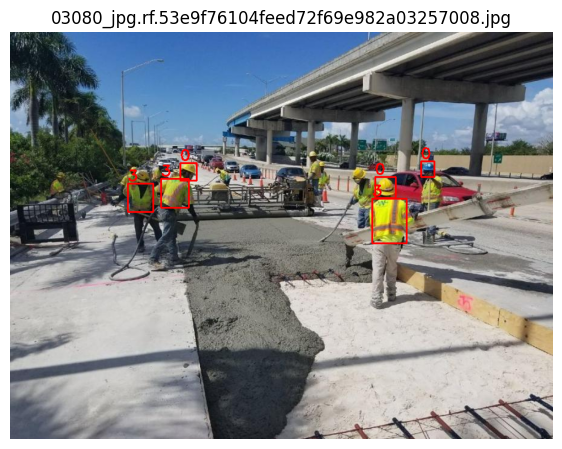

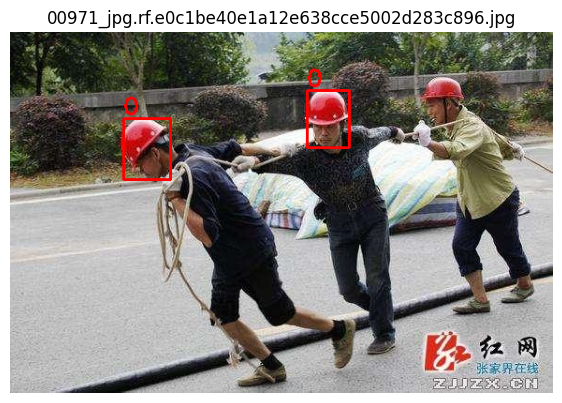

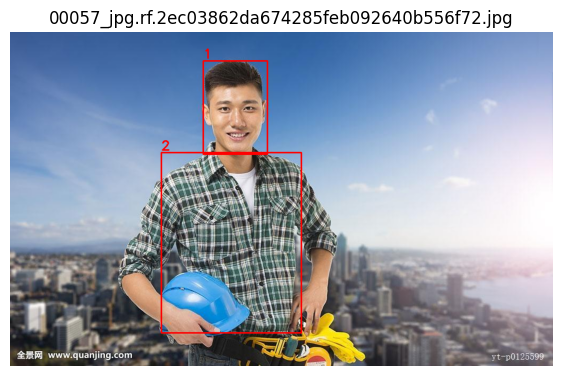

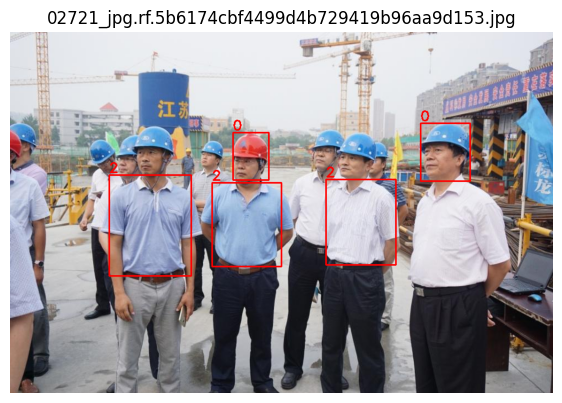

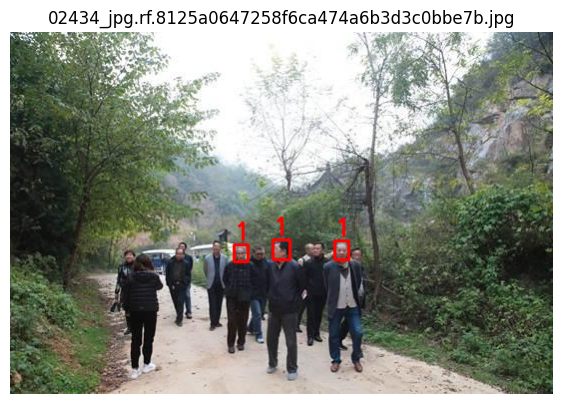

In [8]:
import cv2
import matplotlib.pyplot as plt
import random

def show_sample_with_boxes(img_dir, lbl_dir, n=3):
    img_paths = [p for p in img_dir.iterdir() if p.suffix.lower() in img_exist]
    picks = random.sample(img_paths, k=min(n, len(img_paths)))

    for img_path in picks:
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]

        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if lbl_path.exists():
            lines = lbl_path.read_text().strip().splitlines()
        else:
            lines = []

        for line in lines:
            c, xc, yc, w, h = line.split()
            xc, yc, w, h = map(float, [xc, yc, w, h])

            x1 = int((xc - w/2) * W)
            y1 = int((yc - h/2) * H)
            x2 = int((xc + w/2) * W)
            y2 = int((yc + h/2) * H)

            cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
            cv2.putText(img, str(int(float(c))), (x1, max(0,y1-5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,0,0), 2)

        plt.figure(figsize=(7,7))
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_path.name)
        plt.show()

show_sample_with_boxes(TRAIN_IMG, TRAIN_LABEL, n=5)


# **Buat Data.yaml**

In [9]:
DATASET_DIR = Path('/kaggle/input/dataset-of-personal-protective-equipment-ppe/20250731-ppe2286y').resolve()

names = ["helmet", "no helmet", "no vest", "vest"]

data_yaml = {
    "path" :  str(DATASET_DIR),
    "train" : "train/images",
    "val" : "valid/images",
    "names" : names
}

with open("data.yaml", "w") as f:
  yaml.safe_dump(data_yaml, f, sort_keys=False)

print("data.yaml dibuat")

data.yaml dibuat


# **TRAINING MODEL**

In [10]:
model = YOLO("yolo12s.pt")
model.train(
    data="data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    patience=20,
    close_mosaic=10
)

Ultralytics 8.4.2 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, plots=True, pose=12.0, pretrained

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7dbaba1aefc0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [11]:
import shutil
import os

src = "runs/detect/train5/weights/best.pt"
dst = "/kaggle/working/best.pt"

shutil.copy(src, dst)
print("Saved to:", dst, "| exists:", os.path.exists(dst))



FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/train5/weights/best.pt'